# EXPLORATORY DATA ANALYSIC ON VIDEO GAME SALES DATASET

#### We will be exploring the video game sales with ratings dataset and gethering insights.

#### First we import the required libraries.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

#setting stlying for our plots.
plt.style.use('dark_background')
sns.set_palette('Blues')

#### We start by reading our csv file and storing it as df.

In [2]:
df = pd.read_csv('../data/Video_Games_Sales_as_at_22_Dec_2016.csv')

## Understanding the raw data.

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


#### Skimming through the data we can see various sales and ratings column. We also observe few NaN values in some of the columns.
#### Let's further explore the properties of our dataset.

In [4]:
df.shape

(16719, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


#### Notice a few discrepency in our dataset? To name a few, the critic score is scored on a scale of 0-100 and user score from 0-10 which should be fixed for consistency among them. Our '*Year_of_Release*' column has float instead of int as datatype, '*2006.0*' instead of '*2006*'. Same data type issue with the '*User_Score*' column which is object type instead of int.
#### Let's check for some other patterns in out dataset.

In [6]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [7]:
df.nunique()

Name               11562
Platform              31
Year_of_Release       39
Genre                 12
Publisher            581
NA_Sales             402
EU_Sales             307
JP_Sales             244
Other_Sales          155
Global_Sales         629
Critic_Score          82
Critic_Count         106
User_Score            96
User_Count           888
Developer           1696
Rating                 8
dtype: int64

#### Here we can identify which columns have categorical or numerical values.

In [8]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

#### This cell output holds a lot of info on how we clean our data. It will be explored in the data cleaning section below.

## Data Cleaning

In [9]:
df = df.dropna(axis=0, subset=['Name','Year_of_Release'])

#### We easily cleaned these two columns as they each had only 2 rows of Nan values.

In [10]:
df['Publisher'] = df['Publisher'].fillna('Unknown')

#### We can easily categorise the NaN values for '*Publisher*' column as '*Unknown*' publishers. Reason: if we do any groupby('Publisher') later, NaN rows get silently excluded which can skew results.

In [11]:
df['Year_of_Release'] = df['Year_of_Release'].astype(int)
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
df['User_Score'] = df['User_Score'] * 10

#### Here we did a lot of things. We fixed the data types, scaled the ratings on a scale of 100 for both user and critic rating. Lat's check the unique values of each column, critic ratings, user ratings and year to see if there is still any cleaning left to do.

In [12]:
critic = df['Critic_Score'].unique()
user = df['User_Score'].unique()
year = df['Year_of_Release'].unique()
critic.sort()
user.sort()
year.sort()
critic, user, year

(array([13., 17., 19., 20., 21., 23., 24., 25., 26., 27., 28., 29., 30.,
        31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
        44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
        57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
        70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.,
        83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95.,
        96., 97., 98., nan]),
 array([ 0.,  2.,  3.,  5.,  6.,  7.,  9., 10., 11., 12., 13., 14., 15.,
        16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28.,
        29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
        42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54.,
        55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67.,
        68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80.,
        81., 82., 83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93.,
        94., 95., 96.

#### Looks good. Now let's have a look at our cleaned data again.

In [13]:
display(df.head())
display(df.isnull().sum())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,80.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,83.0,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,80.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8465
Critic_Count       8465
User_Score         8985
User_Count         8985
Developer          6541
Rating             6679
dtype: int64

#### Notice how we still have a lot of NaN values of '*Rating*' related columns. Let's see if we should drop it.

In [14]:
df['Critic_Score'].isnull().sum() / df.shape[0] * 100

np.float64(51.46522373540856)

#### Here wel calculate if we drop the '*Critic_Score*' column with NaN values it will remove approximately 50% of our whole dataset. 
#### We don't want to so much our data so instead we create a sub-dataset for later use which will have all NaN values dropped.

In [15]:
df_ratings = df.dropna(subset=['Critic_Score', 'User_Score', 'Rating'])
df_ratings.shape

(6826, 16)

## Univariate EDA

#### Let's have a look at different columns.

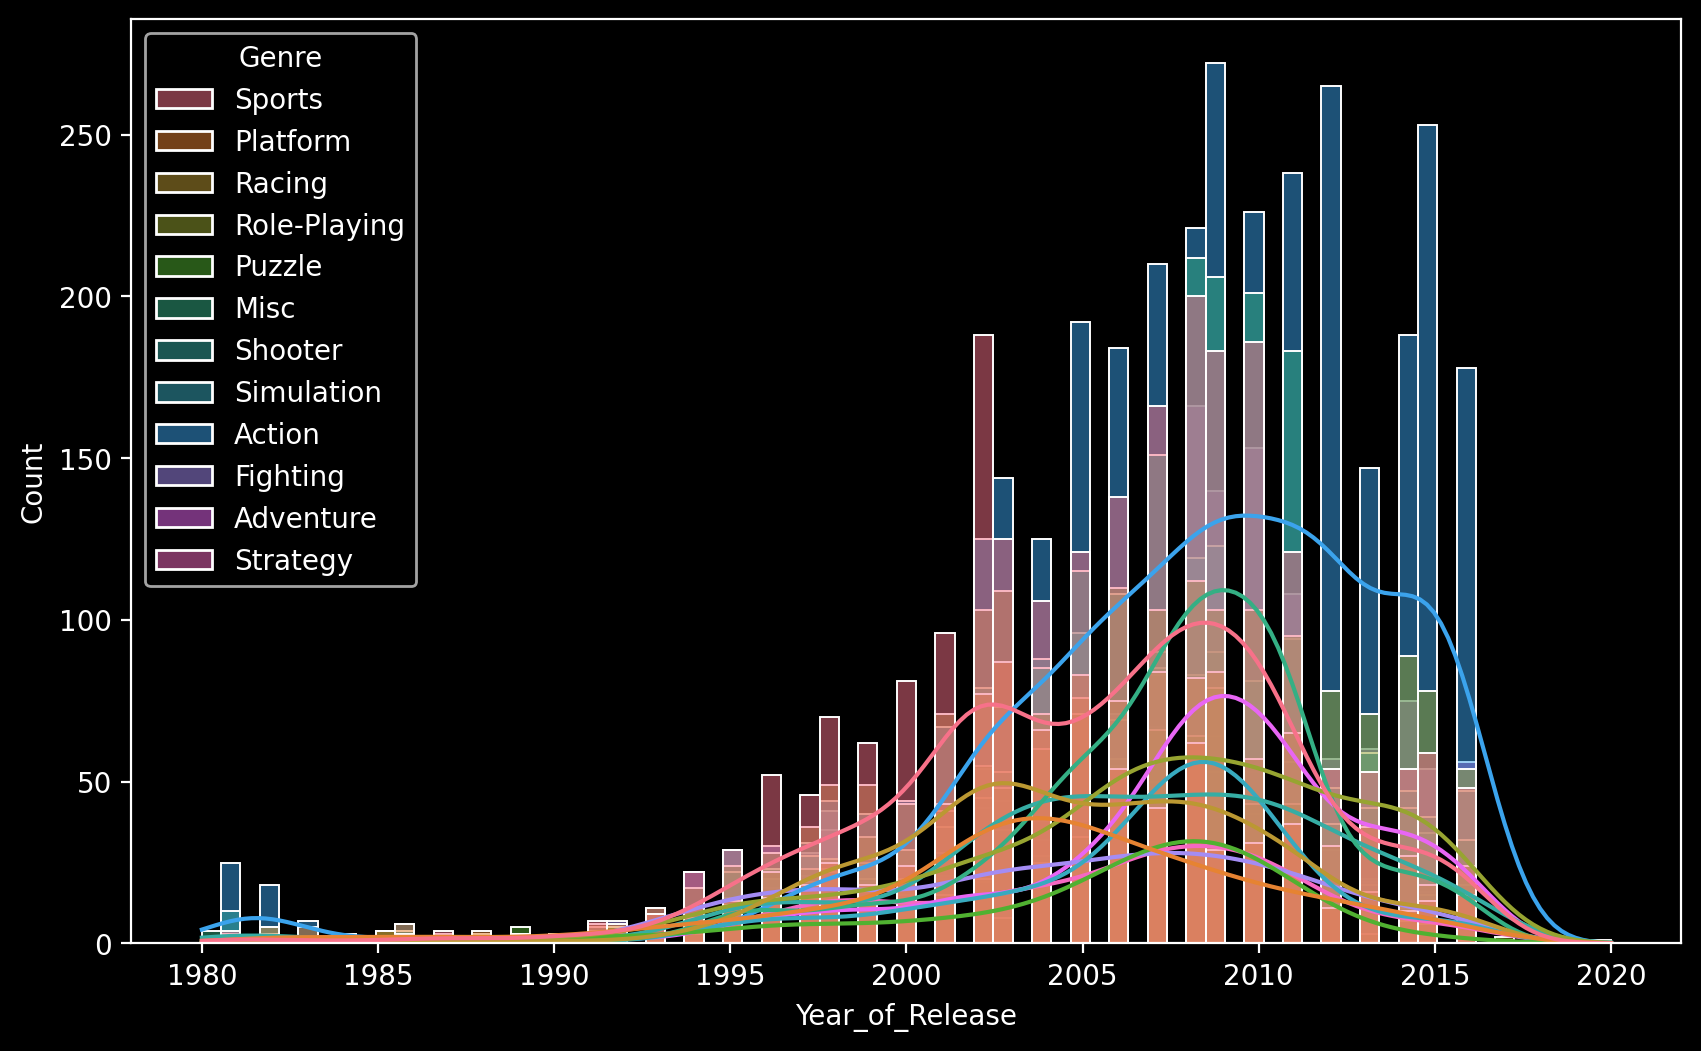

In [16]:
fig, ax = plt.subplots(figsize=(10,6), dpi=200)
sns.histplot(data=df,x='Year_of_Release', hue='Genre', kde=True)
plt.show()

- 2010 peak = most games released, Action genre dominating releases
- Pre-2000 = Sports titles made up a larger share of releases
- 1983-1990 dip = fewer releases (likely reflects the video game crash of 1983 and it's recovery period)

#### Let's exlore some other columns to find any insight.

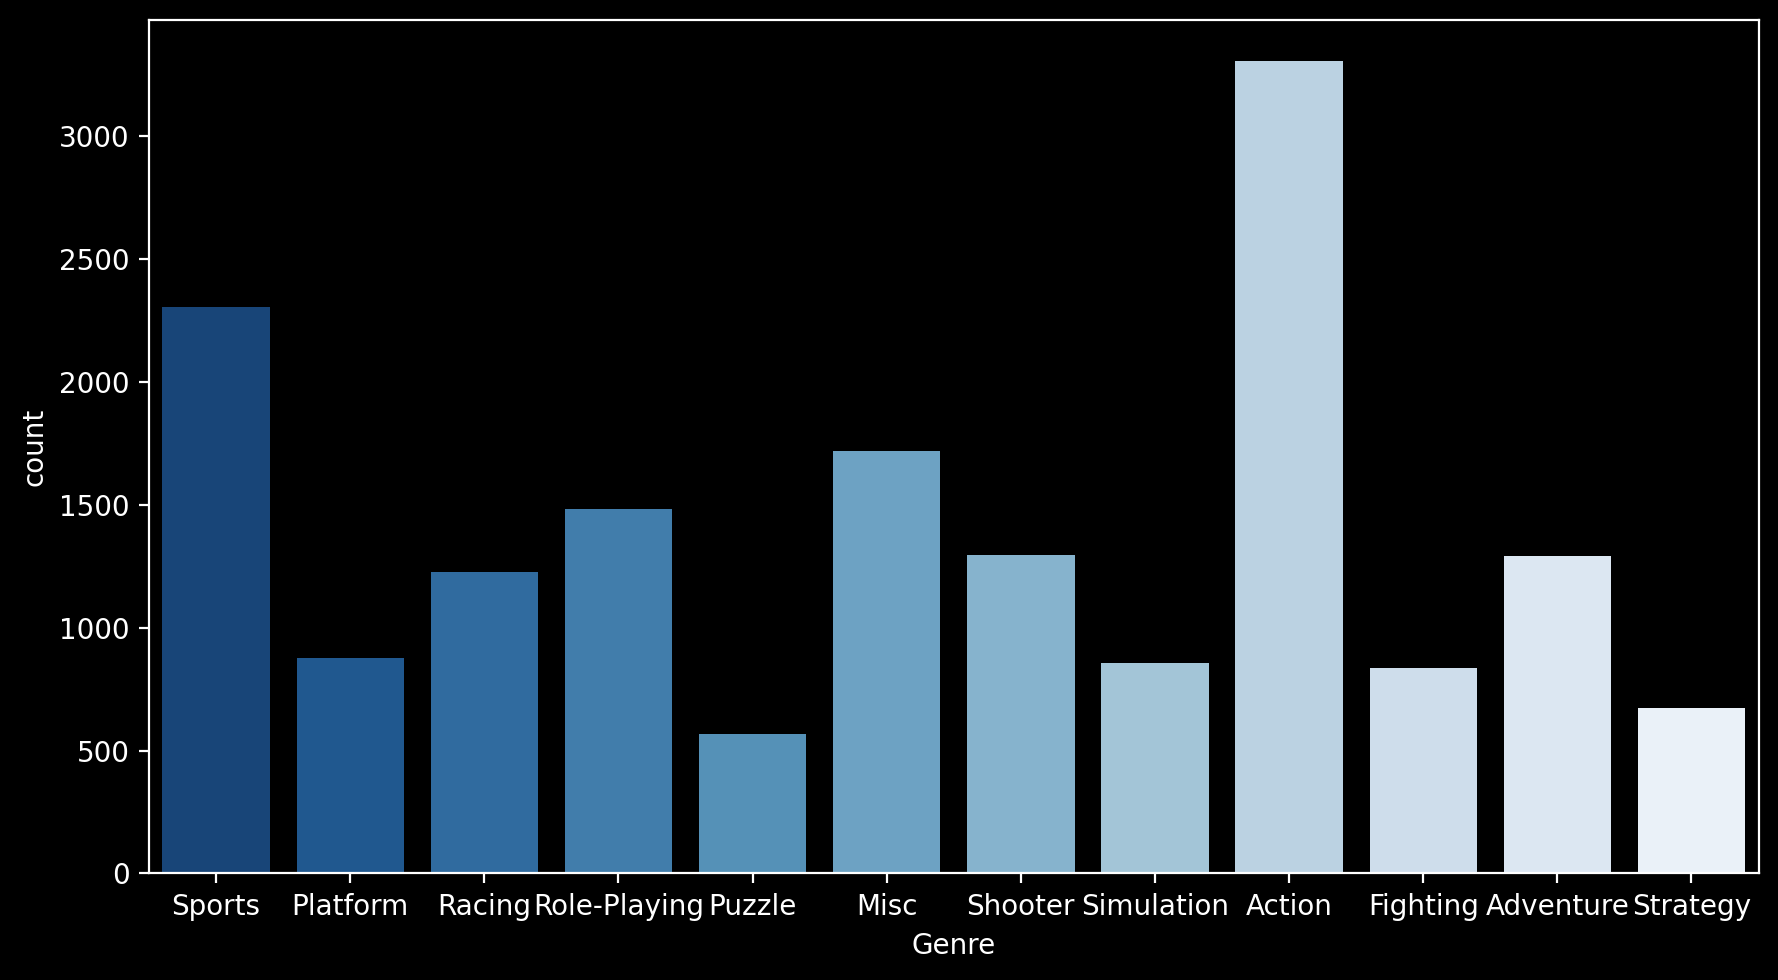

In [17]:
fix, ax = plt.subplots(figsize=(9,5), dpi=200)
sns.countplot(data=df, x='Genre', palette='Blues_r', hue='Genre')
plt.tight_layout()
plt.show()

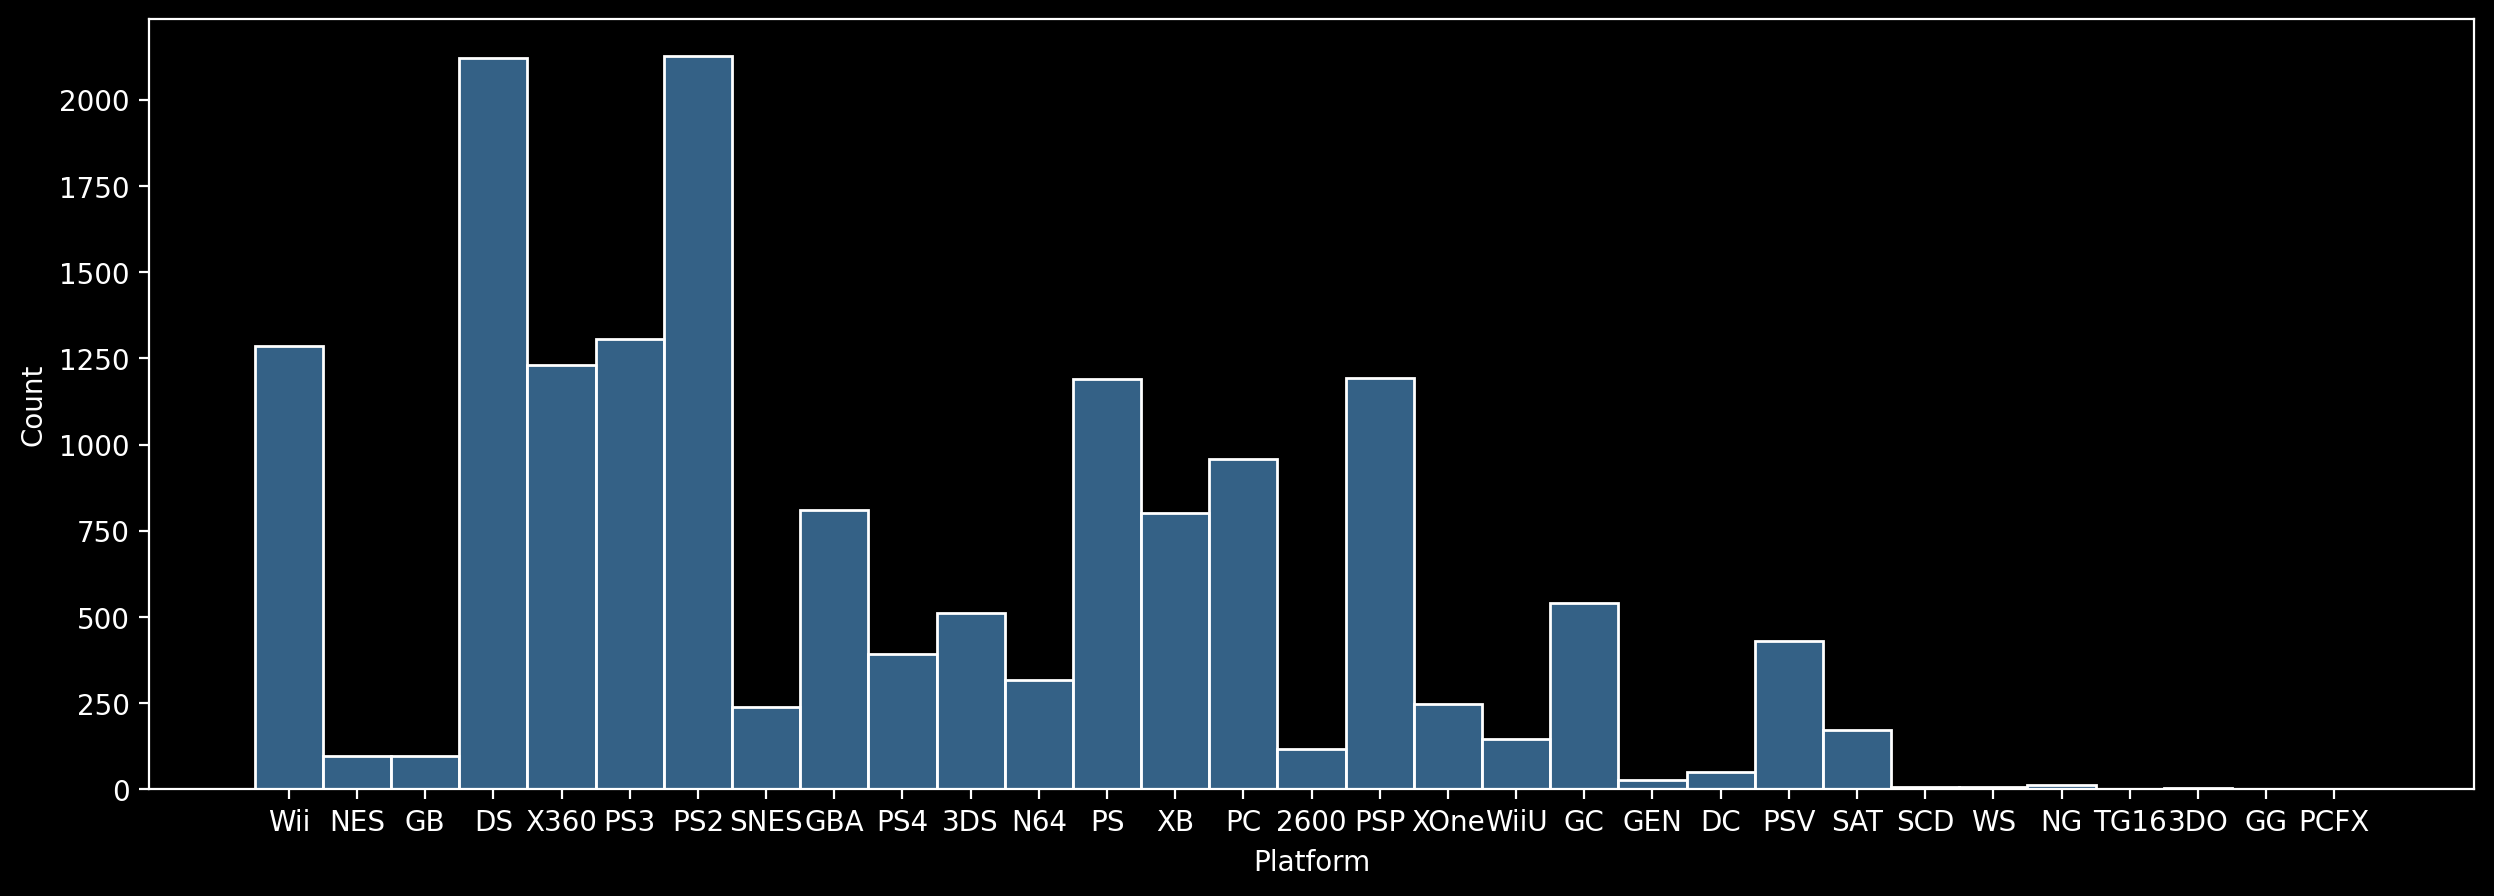

In [18]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Platform', color='steelblue')
plt.show()

#### These distributions represent the number of games released rather than their commercial success. Action is by far the most common genre, followed by Sports, while a few platforms account for a large share of all releases. Whether these categories are also the most successful in terms of sales will be investigated in the bivariate analysis.

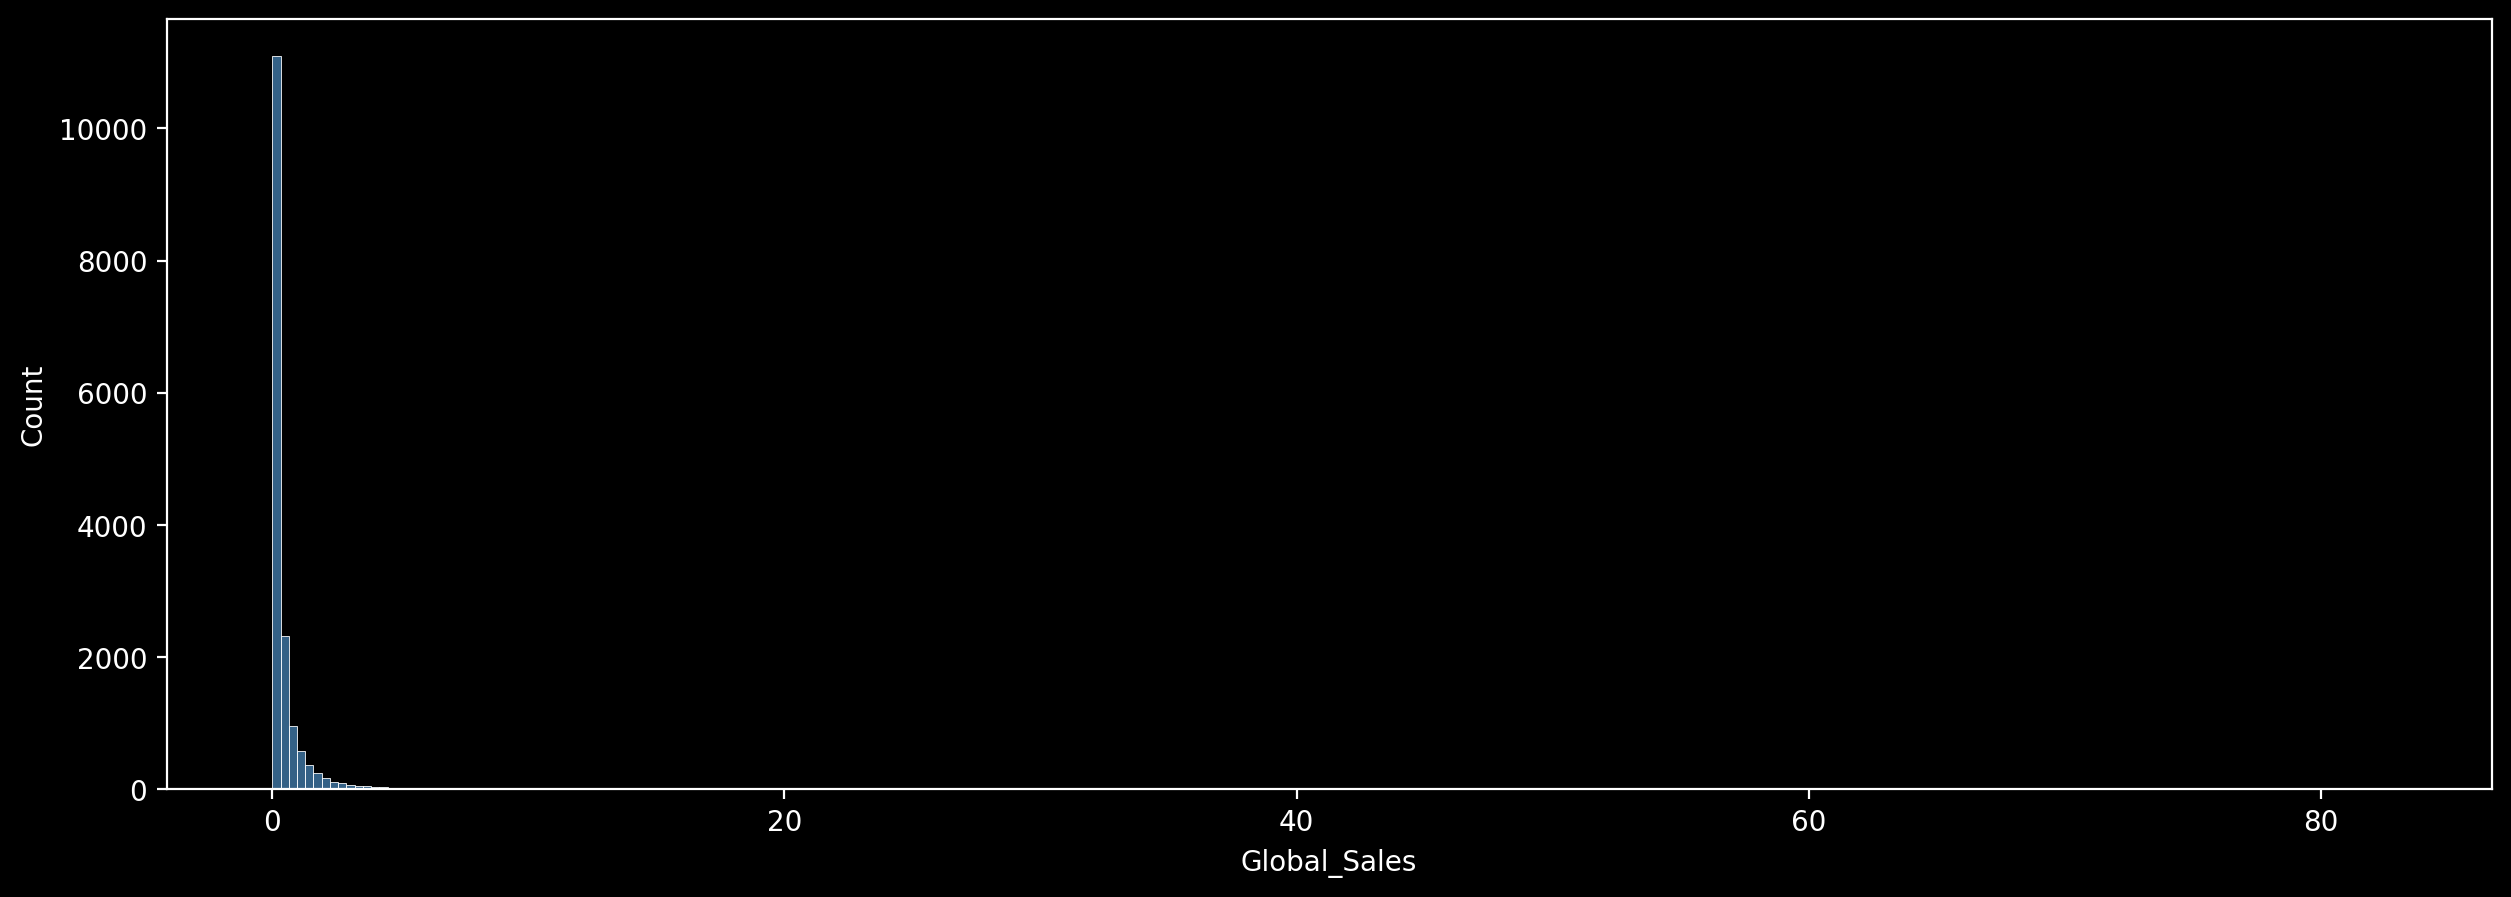

In [19]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Global_Sales', color='steelblue')
plt.show()

#### The distribution of Global Sales is heavily right-skewed. Most games sold relatively few copies, while only a handful became massive commercial successes. These blockbuster titles appear as extreme outliers and pull the distribution towards the right.

In [20]:
percentage = (df['Global_Sales'] < 1).sum() / len(df) * 100
print(f'\nPercentage of titles that sold less than a million copies: {percentage}')


Percentage of titles that sold less than a million copies: 87.5182392996109


#### To quantify this observation, we calculated the percentage of games that sold fewer than one million copies. Approximately **87.6%** of all titles fall below this threshold, showing that commercial success is concentrated among a relatively small number of games while the majority achieve modest sales.

#### Let's see if the same trend is followed in regional sales.

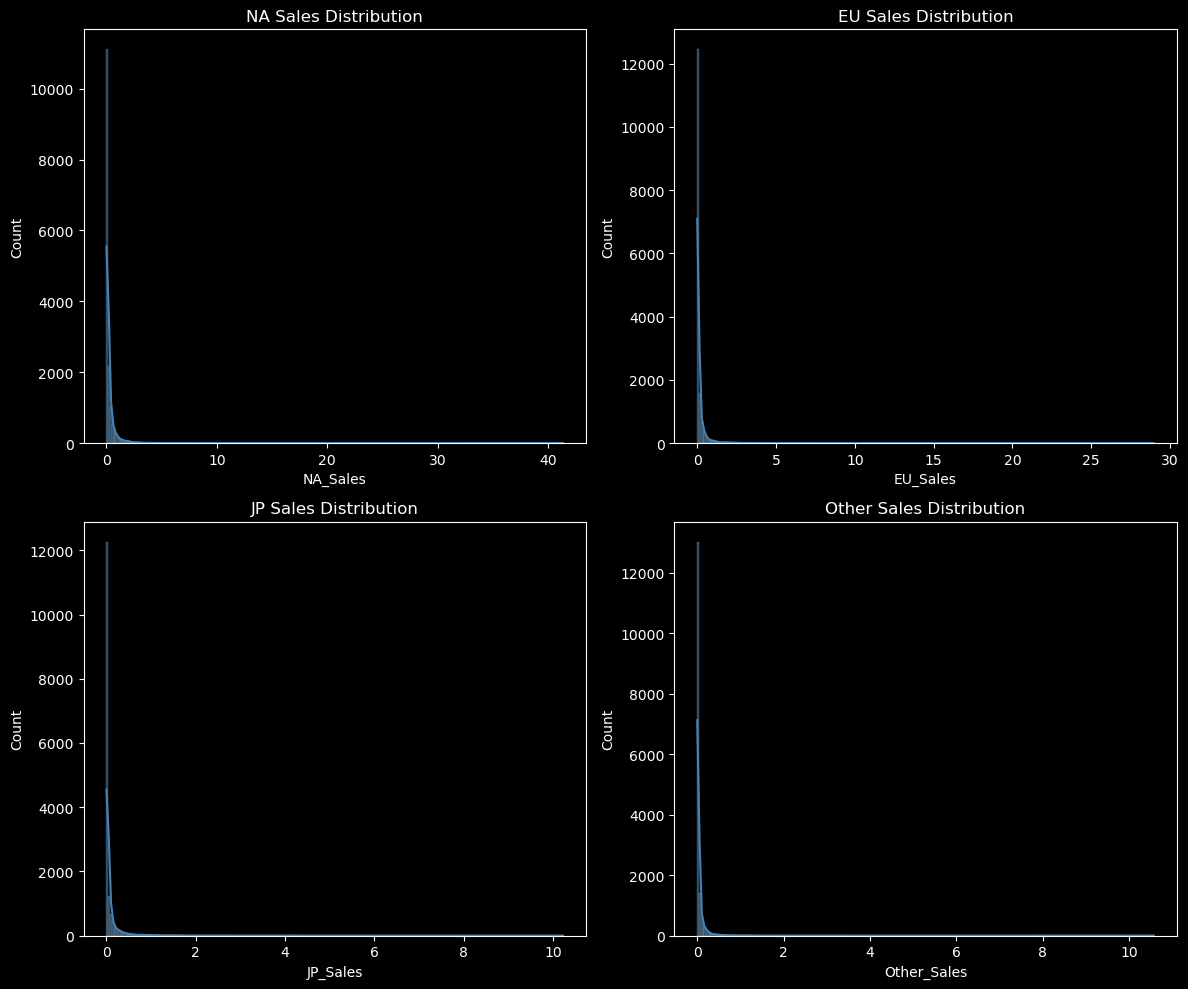

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=df, x='NA_Sales', ax=axes[0,0], kde=True, color='steelblue')
axes[0,0].set_title('NA Sales Distribution')

sns.histplot(data=df, x='EU_Sales', ax=axes[0,1], kde=True, color='steelblue')
axes[0,1].set_title('EU Sales Distribution')

sns.histplot(data=df, x='JP_Sales', ax=axes[1,0], kde=True, color='steelblue')
axes[1,0].set_title('JP Sales Distribution')

sns.histplot(data=df, x='Other_Sales', ax=axes[1,1], kde=True, color='steelblue')
axes[1,1].set_title('Other Sales Distribution')

plt.tight_layout()
plt.show()

#### All regional sales distributions exhibit a similar right-skewed pattern, suggesting that blockbuster games are uncommon regardless of region. Most titles record relatively low sales, while only a few achieve exceptional commercial performance across each market.

#### Now let's also have a look at our top publishers.

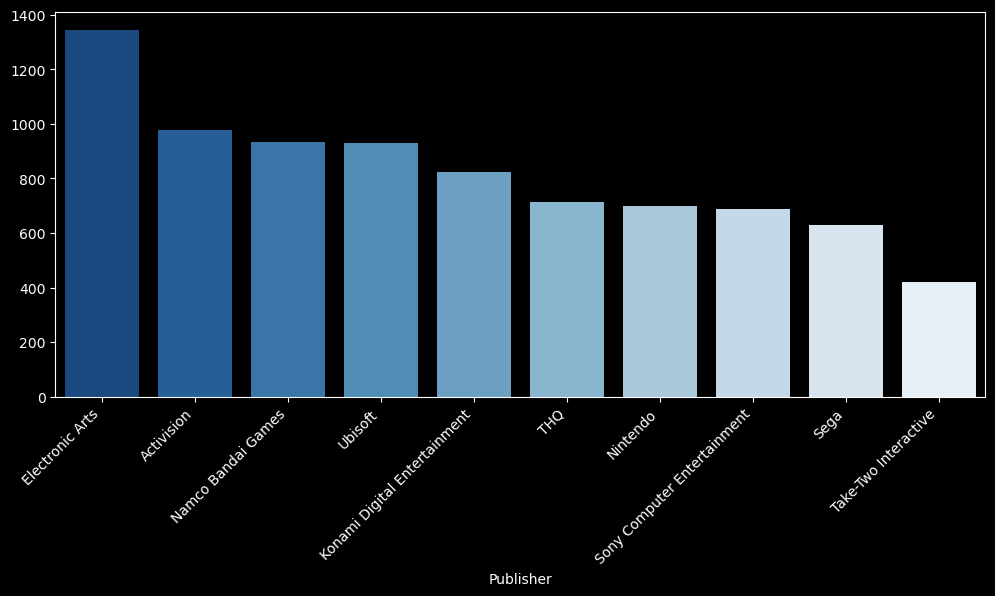

In [22]:
top10_publishers = df['Publisher'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x=top10_publishers.index, y=top10_publishers.values, palette='Blues_r', hue=top10_publishers.index)
plt.xticks(rotation=45, ha='right')
plt.show()

## Bivariate EDA sales focused

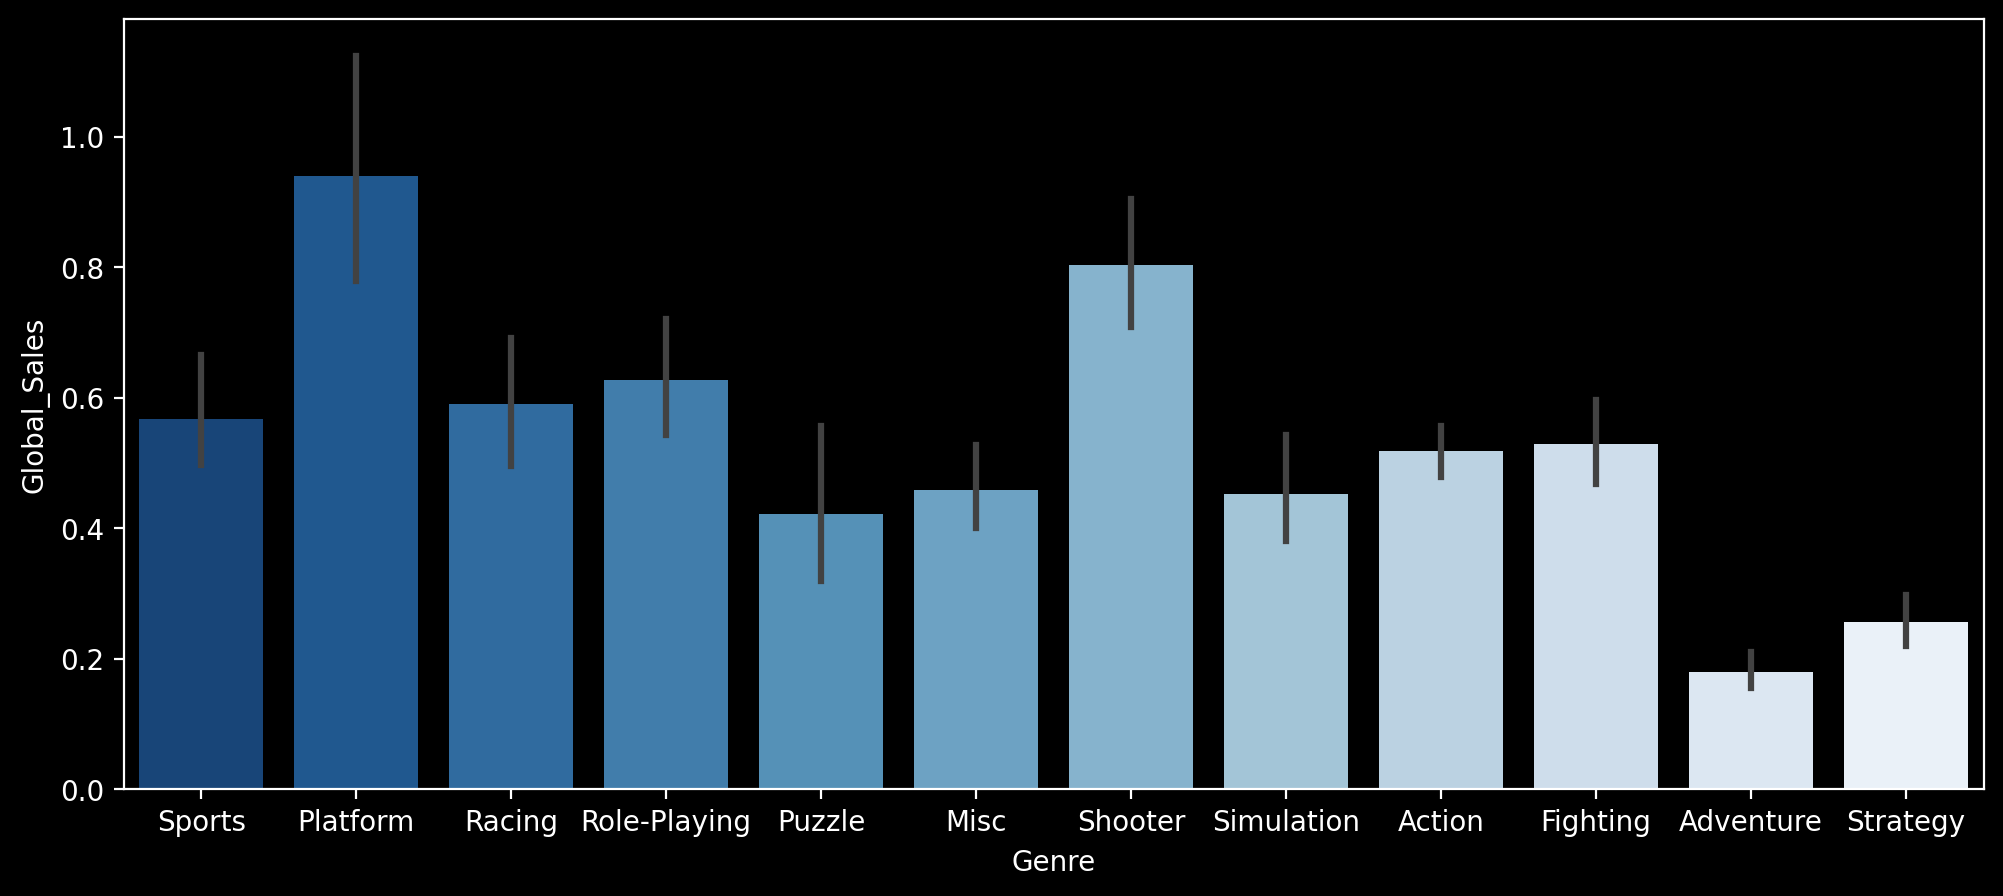

In [23]:
fig, ax = plt.subplots(figsize=(12,5), dpi=200)
ax = sns.barplot(df, x='Genre', y='Global_Sales', hue='Genre', palette='Blues_r')

#### Recall that Action and Sports dominated in number of releases, making them the most prolific genres in the dataset. However, release volume doesn't equal commercial success. When we examine average Global Sales per genre, the picture shifts entirely — Platform and Shooter games rise to the top despite having far fewer releases. Action games, while overwhelming in quantity, rank considerably lower in average sales per title. This reveals an important distinction: the most frequently made games are not necessarily the best selling ones. Platform and Shooter titles may be rarer, but when they release, they tend to sell significantly better.

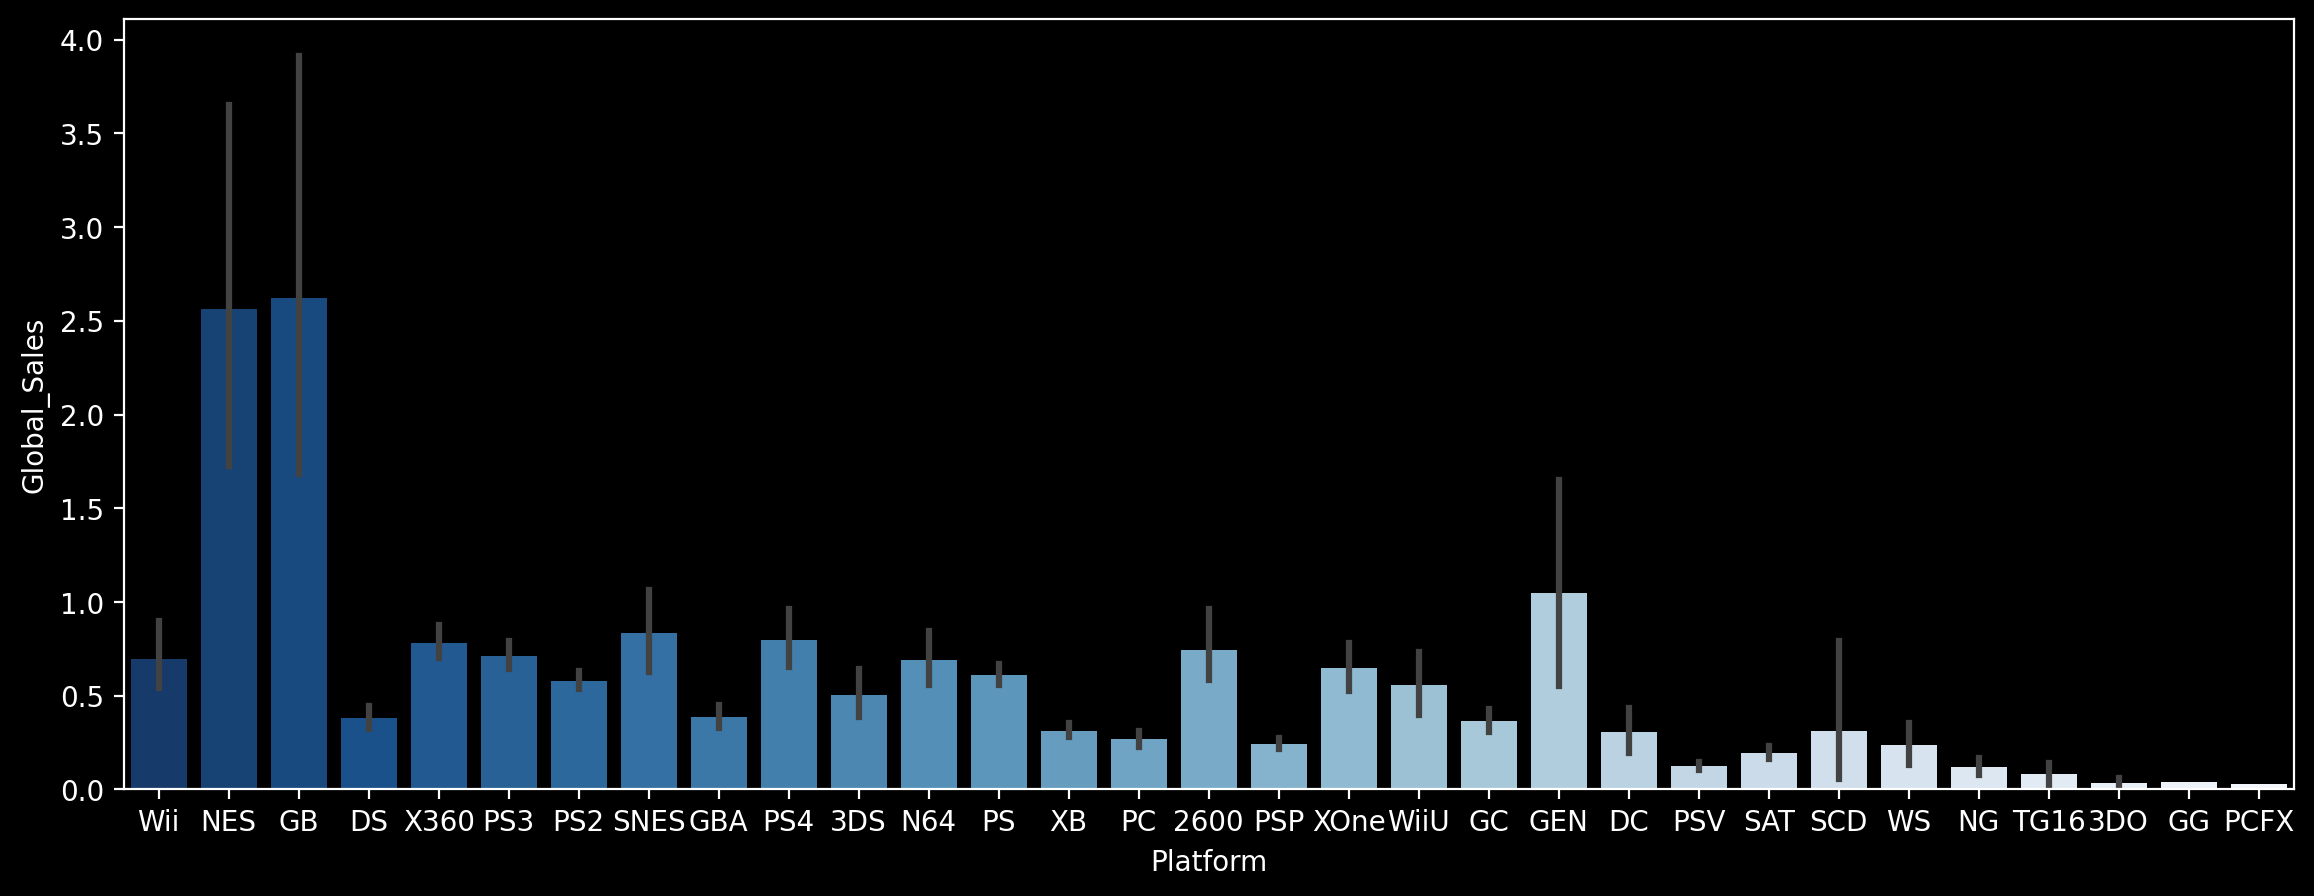

In [24]:
fig, ax = plt.subplots(figsize=(14,5), dpi=200)
ax = sns.barplot(df, x='Platform', y='Global_Sales', hue='Platform', palette='Blues_r')

#### A similar pattern is observed across gaming platforms. Platforms with a large number of released titles do not always generate the highest average sales per game, indicating that quantity alone is not a reliable indicator of commercial success.

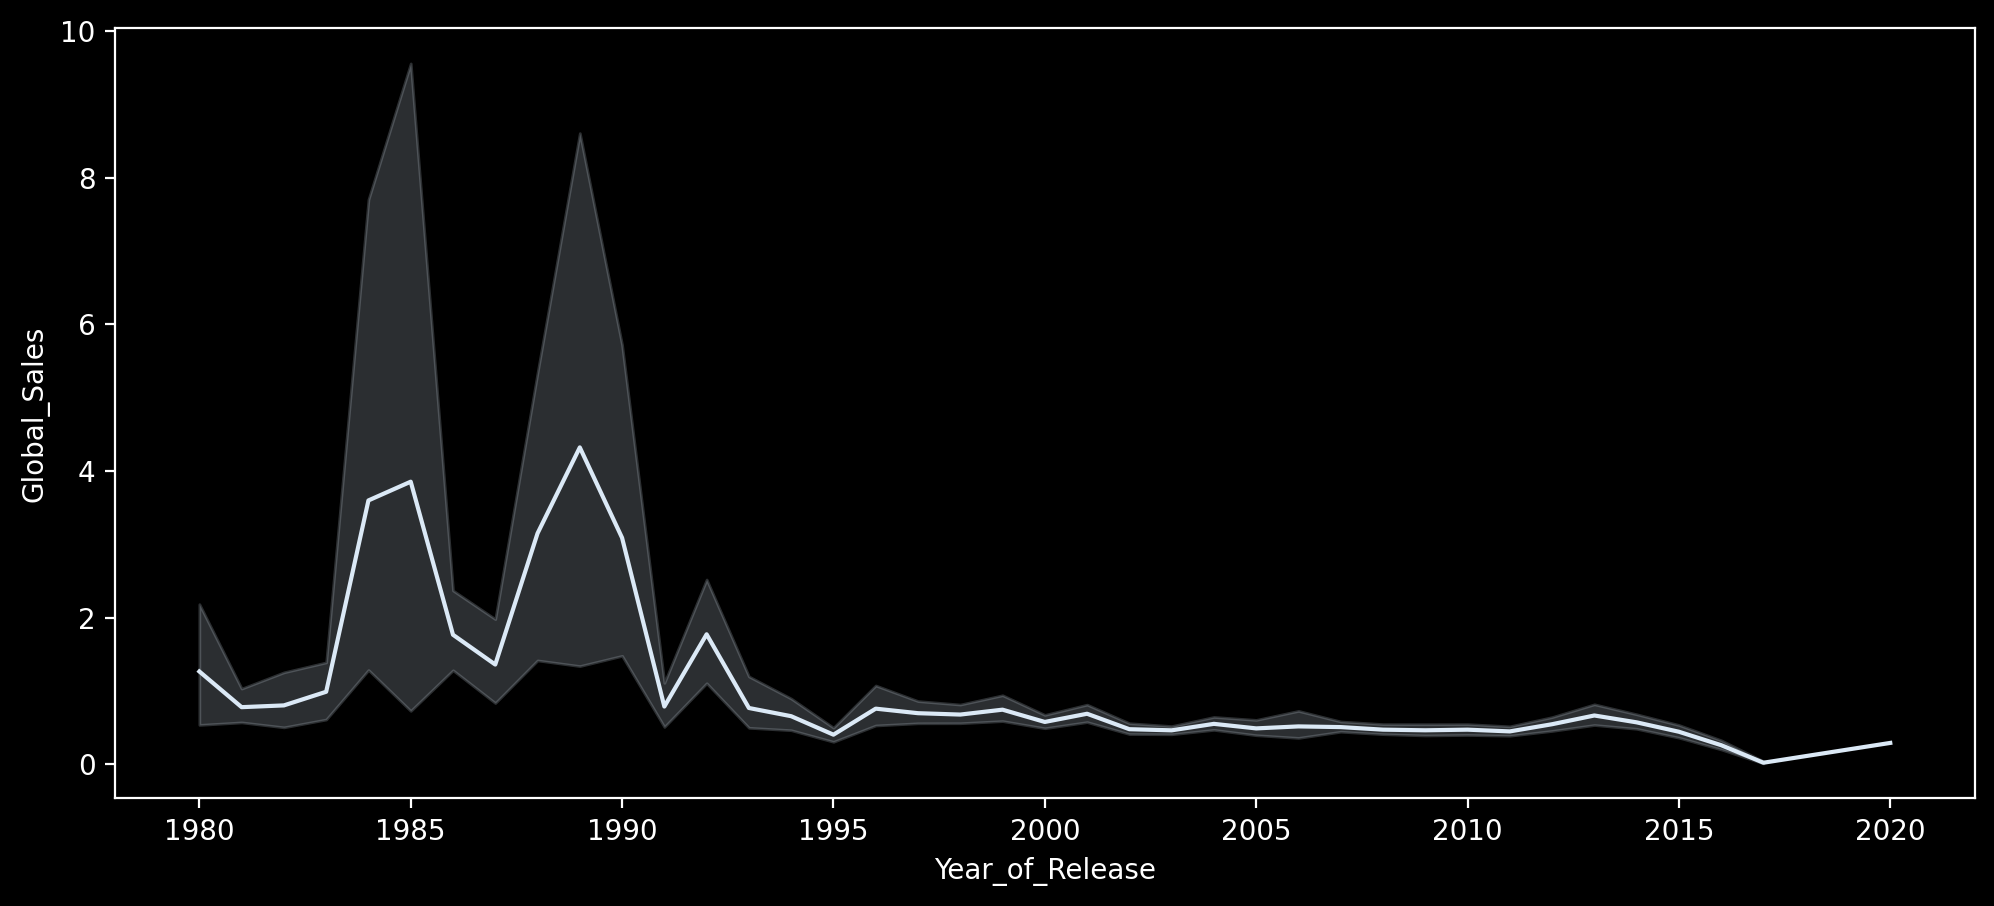

In [45]:
fig, ax = plt.subplots(figsize=(12,5), dpi=200)
ax = sns.lineplot(df, x='Year_of_Release', y='Global_Sales')

#### Average Global Sales generally decline for more recent release years. This trend should be interpreted cautiously, as newer games have had less time to accumulate lifetime sales than older releases, introducing a natural recency bias into the dataset.

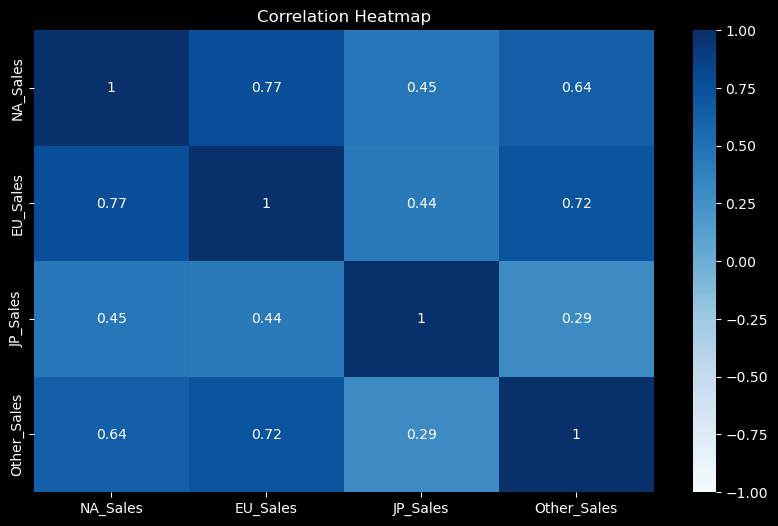

In [26]:
corr_matrix = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

#### NA and EU sales are strongly correlated (0.77), meaning games that sell well in one western market tend to sell well in the other — both markets respond similarly to the same titles. JP Sales shows a much weaker correlation with both NA (0.45) and EU (0.44), indicating that Japan's market behaves more independently — a blockbuster in the west does not reliably translate to strong Japanese sales, and vice versa.

## Bivariate ratings focused

#### Remember the sub-dataset we created earlier, we will use that data set to perform ratings based EDA.

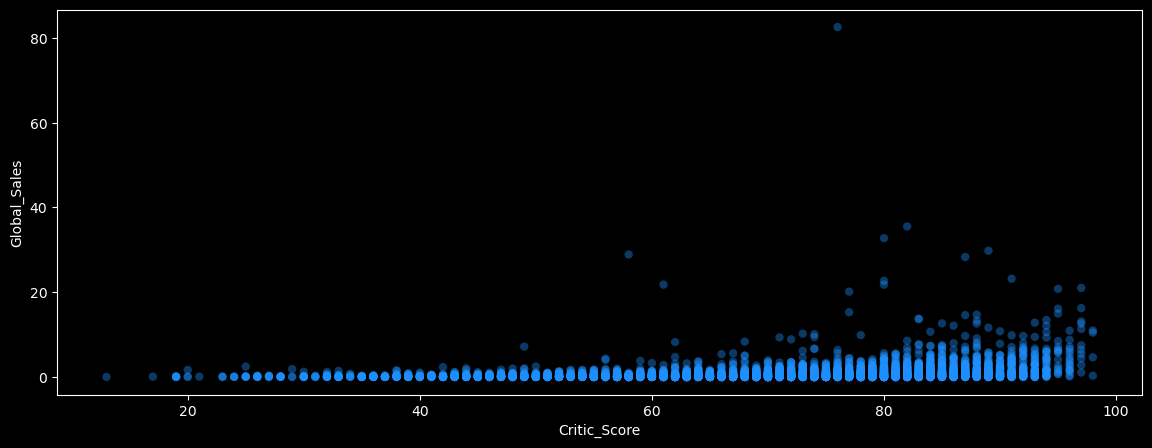

In [27]:
fig, ax = plt.subplots(figsize=(14,5))
sns.scatterplot(data=df_ratings, x='Critic_Score', y='Global_Sales', color='dodgerblue', alpha=0.4, edgecolor='none')
plt.show()

#### In our earlier univariate analysis, we observed a strong right skew in Global Sales. This scatterplot of Critic Score vs Global Sales shows the same skew persisting — a single point sits dramatically above the rest of the distribution. Let's identify what's causing it.

In [28]:
display(df_ratings.nlargest(5, 'Global_Sales'))
display(df_ratings.nlargest(2, 'Global_Sales')[['Name','Global_Sales']])

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,80.0,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,83.0,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,80.0,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,85.0,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,66.0,129.0,Nintendo,E


,Name,Global_Sales
0,Wii Sports,82.53
2,Mario Kart Wii,35.52


#### The culprit is Wii Sports, with 82.53 million copies sold — nearly double the second highest seller, Mario Kart Wii at 35.52 million. This is not a case of organic demand; Wii Sports was bundled with every Wii console sold, meaning its sales reflect console adoption rather than a deliberate purchase decision. For our analysis of Critic Score vs Global Sales, this makes it a misleading data point and we will exclude it from the next plot.

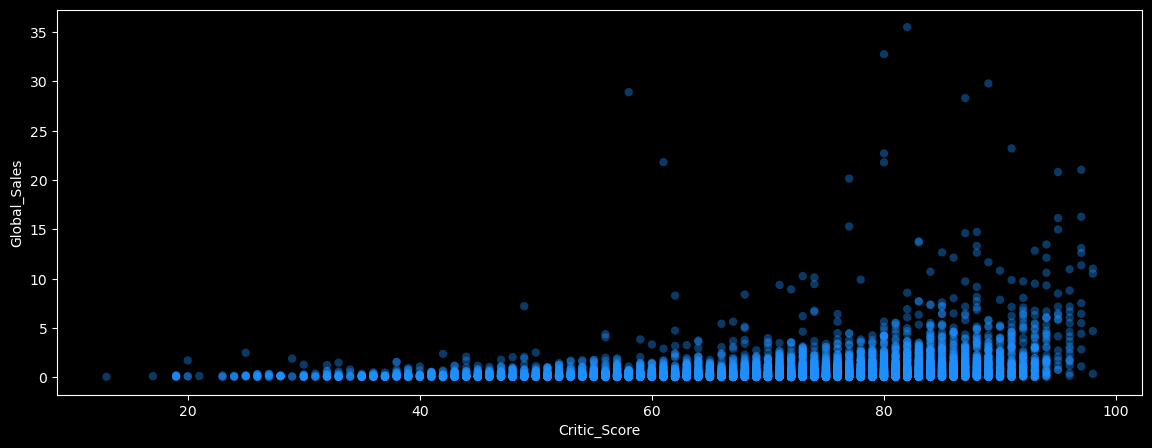

In [29]:
fig, ax = plt.subplots(figsize=(14,5))
df_no_outlier = df_ratings[df_ratings['Name'] != 'Wii Sports']
sns.scatterplot(data=df_no_outlier, x='Critic_Score', y='Global_Sales', color='dodgerblue', alpha=0.4, edgecolor='none')
plt.show()

#### Removing Wii Sports significantly improves the readability of the scatterplot. Since its sales were heavily influenced by being bundled with the Wii console, excluding it allows the underlying relationship between critic scores and commercial performance to be observed more clearly.

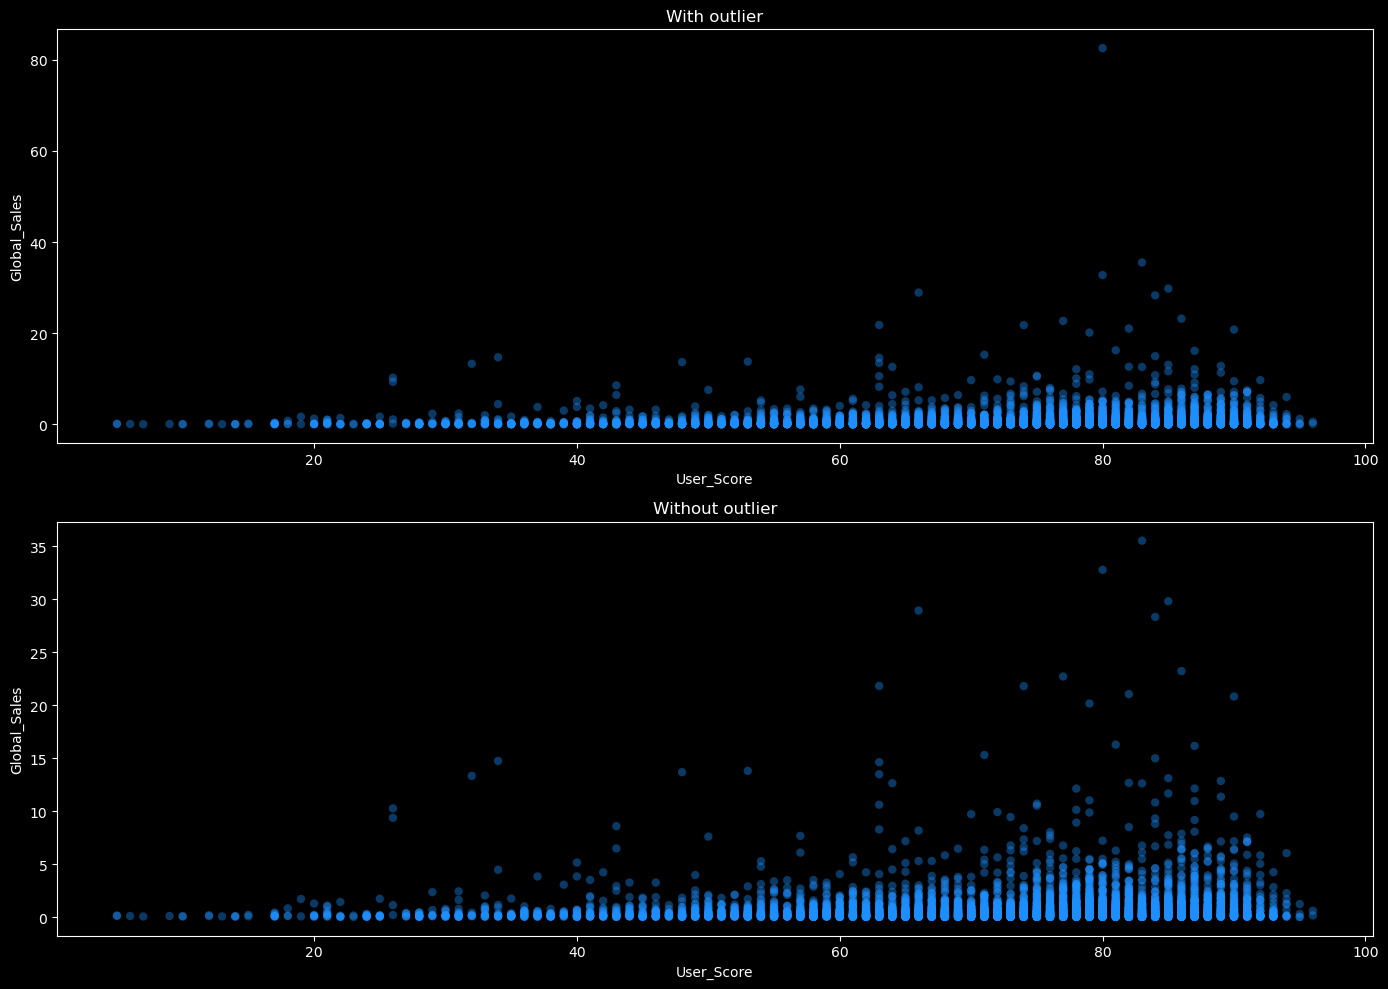

In [30]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))

sns.scatterplot(data=df_ratings, x='User_Score', y='Global_Sales', color='dodgerblue', alpha=0.4, edgecolor='none', ax=ax[0])
ax[0].set_title('With outlier')

df_no_outlier = df_ratings[df_ratings['Name'] != 'Wii Sports']
sns.scatterplot(data=df_no_outlier, x='User_Score', y='Global_Sales', color='dodgerblue', alpha=0.4, edgecolor='none', ax=ax[1])
ax[1].set_title('Without outlier')

plt.tight_layout()
plt.show()

#### Similar to Critic Score, plotting User Score against Global Sales reveals the same Wii Sports outlier dominating the top of the distribution. Removing it in the second plot gives a much cleaner picture — we can now see that higher user scores do show a slight tendency toward better sales, but the relationship is not too strong, suggesting user scores is a predictor of commercial success but not the only one.

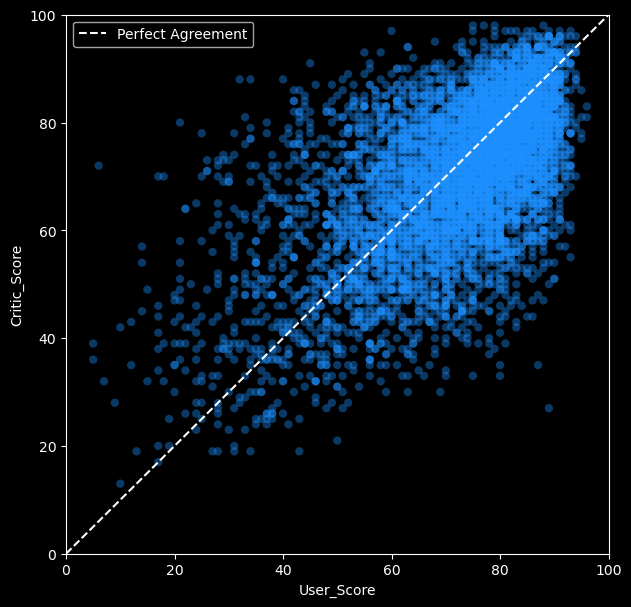

In [31]:
fig, ax = plt.subplots(figsize=(7,7))
sns.scatterplot(data=df_ratings, x='User_Score', y='Critic_Score', color='dodgerblue', alpha=0.4, edgecolor='none', ax=ax)
ax.plot([0,100], [0,100], color='white', linestyle='--', label='Perfect Agreement')
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.legend()
plt.show()

In [32]:
higher = (df_ratings['Critic_Score'] > df_ratings['User_Score']).mean() * 100
lower = (df_ratings['Critic_Score'] < df_ratings['User_Score']).mean() * 100
equal = (df_ratings['Critic_Score'] == df_ratings['User_Score']).mean() * 100

print(f'Critic higher: {higher:.2f}%')
print(f'User higher: {lower:.2f}%')
print(f'Equal: {equal:.2f}%')

Critic higher: 40.68%
User higher: 55.14%
Equal: 4.18%


#### Users rated games higher than critics in approximately **55%** of the observations, while critics assigned higher scores in around **41%**. This pattern is also visible in the scatterplot, where most observations lie below the line of perfect agreement, indicating a slight tendency for users to give more generous ratings.

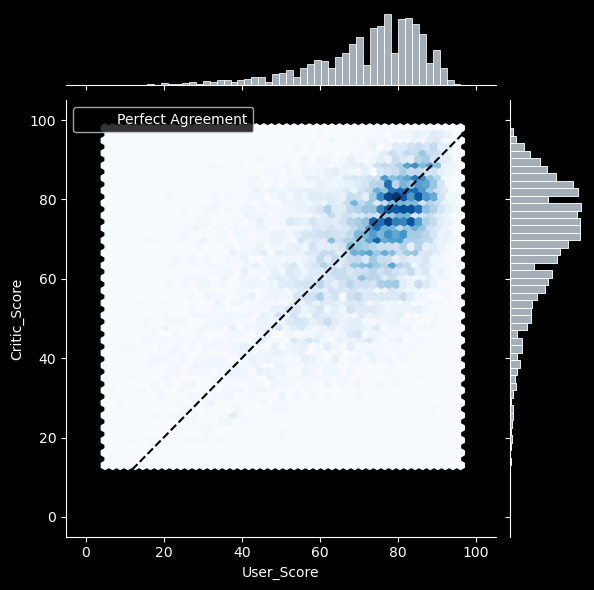

In [44]:
g = sns.jointplot(data=df_ratings, x='User_Score', y='Critic_Score', kind='hex', cmap='Blues')
g.ax_joint.plot([0,100], [0,100], color='black', linestyle='--', label='Perfect Agreement')
g.ax_joint.legend()
plt.show()

#### The densest cluster sits just above the agreement line in the 70-85 range, suggesting critics and users are close but critics edge slightly higher for the most commonly rated games. However, across all games our percentage breakdown tells the fuller story — users score higher in 55.14% of cases overall, meaning the dense cluster is not representative of the whole dataset. Users are marginally more generous on average, but critics tend to rate the most popular mid-to-high tier games slightly higher.

# Final Insights

#### Throughout this exploratory analysis, several consistent patterns emerged:

- The video game industry is highly skewed, with nearly **88%** of titles selling fewer than one million copies while a small number of blockbuster games account for a disproportionate share of total sales.
- Genres and platforms with the highest number of releases are not necessarily the most commercially successful on average, demonstrating that production volume does not directly translate into higher sales.
- Sales patterns differ across regions. North America and Europe exhibit similar purchasing behaviour, whereas Japan follows a more independent market trend.
- Critic and user ratings show only a weak positive relationship with Global Sales. High ratings may contribute to success, but they are far from the only factor influencing commercial performance.
- Wii Sports represents an exceptional outlier whose bundled distribution heavily inflates sales figures, illustrating the importance of investigating and handling influential observations before drawing conclusions.

#### This analysis demonstrates how exploratory data analysis can uncover trends, identify anomalies, validate assumptions, and guide future statistical modelling or predictive machine learning tasks.

# Key Takeaways

#### This analysis answered the following questions:

- What does the distribution of game sales look like?
- Which genres and platforms are most common?
- Which genres achieve the highest average sales?
- How do regional markets differ?
- Are critic and user ratings related to commercial success?
- Which outliers significantly affect the analysis?

#### These findings provide a strong foundation for future predictive modelling, such as estimating game sales using features like genre, platform, release year and review scores.